# Projeto 4 — Álgebra Linear Numérica


---

## Questão 1 — Cálculo dos Refletores de Householder

---
## Item (a) — Derivação de $v$ e $\beta$

**Enunciado:** Mostrar que, para $Q_v x = \|x\|\, e_1$, temos
$$v = x - \|x\|\, e_1, \qquad
\beta = \frac{1}{\|x\|(\|x\| - x_1)}
     = \frac{\|x\| + x_1}{\|x\|(\|x\|^2 - x_1^2)}
     = \frac{\|x\| + x_1}{\|x\| \cdot \|y\|^2},$$
onde $y = (x_2, \ldots, x_n)$.

### Solução

Queremos $Q_v x = \|x\|\,e_1$, ou seja:
$$(I - \beta v v^*) x = \|x\|\, e_1.$$
 
Um refletor de Householder reflete $x$ em $\|x\|e_1$, ou seja, o hiperplano de reflexão é a bissetriz entre $x$ e $\|x\|e_1$. O vetor normal a esse hiperplano é:
$$v = x - \|x\|\, e_1.$$
 
Para que $(I - \beta v v^*) x = \|x\|\, e_1$, precisamos:
$$x - \beta (v^* x)\, v = \|x\|\, e_1.$$

Como $v = x - \|x\|\, e_1$, temos:
$$v^* x = (x - \|x\|\, e_1)^* x = \|x\|^2 - \|x\|\, x_1.$$

Substituindo:
$$x - \beta(\|x\|^2 - \|x\| x_1)\,v = \|x\|\, e_1 \implies \beta(\|x\|^2 - \|x\| x_1)\,v = v.$$

Portanto, desde que $v \neq 0$:
$$\boxed{\beta = \frac{1}{\|x\|^2 - \|x\| x_1} = \frac{1}{\|x\|(\|x\| - x_1)}}.$$

Multiplicando numerador e denominador por $(\|x\| + x_1)$:
$$\beta = \frac{\|x\| + x_1}{\|x\|(\|x\|^2 - x_1^2)}.$$

Como $\|x\|^2 - x_1^2 = x_2^2 + \cdots + x_n^2 = \|y\|^2$ (onde $y = (x_2, \ldots, x_n)$):
$$\boxed{\beta = \frac{\|x\| + x_1}{\|x\| \cdot \|y\|^2}}.$$

**Verificação de ortogonalidade de $Q_v$:**  
Note que $\|v\|^2 = v^* v = \|x\|^2 - 2\|x\| x_1 + \|x\|^2 = 2(\|x\|^2 - \|x\| x_1)$, então $\beta = 2/\|v\|^2$, que é exatamente a condição para que $Q_v = I - \beta vv^*$ seja ortogonal ($Q_v^* = Q_v^{-1} = Q_v$). $\blacksquare$

---
## Item (b) — Cancelamento Numérico

**Enunciado:** Verificar que, dependendo do sinal de $x_1$, uma das fórmulas para $\beta$ não está sujeita a cancelamento numérico.

### Solução

As duas formas candidatas para o denominador de $\beta$ são:
- **Forma 1:** $\|x\|(\|x\| - x_1)$
- **Forma 2:** $\|x\|(\|x\| + x_1)$ (no denominador da expressão $\beta = (\|x\|+x_1)/(\|x\|\|y\|^2)$, veja a relação com a Forma 1)

O problema é que $v_1 = x_1 - \|x\|$ pode sofrer cancelamento:

| Sinal de $x_1$ | $v_1 = x_1 - \|x\|$ | Problema |
|:---:|:---:|:---:|
| $x_1 > 0$ | $x_1 - \|x\| \approx 0$ se $x \approx \|x\|e_1$ | **Cancelamento em $v_1$** |
| $x_1 < 0$ | $x_1 - \|x\| \approx 2x_1$, sem cancelamento | Seguro |

Para o escalar $\beta$, vejamos a fórmula $\beta = 1/(\|x\|(\|x\| - x_1))$:

- Se $x_1 > 0$: o termo $\|x\| - x_1 \approx 0$ quando $x \approx \|x\|e_1$, causando cancelamento no denominador.
- Se $x_1 < 0$: $\|x\| - x_1 = \|x\| + |x_1| > \|x\|$, não há cancelamento.

A fórmula alternativa $\beta = (\|x\| + x_1)/(\|x\| \cdot \|y\|^2)$ funciona quando $x_1 > 0$ (pois $\|x\| + x_1 \geq \|x\|$), mas falha quando $x_1 < 0$.

Estratégia numericamente estável: escolher o sinal de $\|x\|$ oposto ao de $x_1$, ou seja, usar $\sigma = -\text{sign}(x_1)$ e definir:
$$v_1 = x_1 + \sigma\|x\|, \quad \beta = \frac{-\sigma}{\|x\| v_1} = \frac{1}{|v_1| \cdot \|x\|}, \quad Q_v x = -\sigma\|x\|\,e_1.$$

Com essa escolha, $v_1 = x_1 + \sigma \|x\|$ nunca é pequeno (pois $x_1$ e $\sigma\|x\|$ têm o mesmo sinal), eliminando o cancelamento.

---
## Item (c) — Implementação: `reflector(x)`

A função recebe um vetor $x$ e retorna $(v, \beta)$ tal que $Q_v x = \|x\|\,e_1$ com diagonal positiva (i.e., reflete sempre em $+\|x\|e_1$, forçando $v_1 \leq 0$).

In [19]:
using LinearAlgebra

function reflector(x)
    n = length(x)
    nrmx = norm(x)
    v = copy(x)

    if x[1] > 0
        nrmy2 = sum(x[i]^2 for i in 2:n)
        # Fórmula estável para v[1] quando x[1] > 0 (item g):
        # v[1] = x[1] - ||x|| sofre cancelamento numérico quando x ~= ||x||e_1.
        # Usando a identidade (x[1] - ||x||)(x[1] + ||x||) = -||y||^2,
        # reescrevemos: v[1] = -||y||^2 / (x[1] + ||x||), sem cancelamento.
        v[1] = -nrmy2 / (x[1] + nrmx)
        beta  = (nrmx + x[1]) / (nrmx * nrmy2)
    else
        v[1] -= nrmx  # x[1] <= 0: sem cancelamento, pois x[1] e -||x|| têm mesmo sinal
        beta  = one(eltype(v)) / (nrmx * (-v[1]))
    end

    return v, beta
end

reflector (generic function with 1 method)

---
## Item (d) — Condicionamento de $v$ em relação a $x$

**Enunciado:** Mostrar que a derivada de $v$ em relação a $x$ é $J = I - e_1 x^* / \|x\|$ e que o número de condicionamento absoluto de $v$ em relação a $x$ é $\leq 2$.

### Solução

**Derivada de $v$:** Temos $v(x) = x - \|x\|\,e_1$. A derivada da norma $\|x\| = (x^*x)^{1/2}$ em relação a $x$ é $x^*/\|x\|$. Aplicando isso, obtemos diretamente a matriz Jacobiana:
$$J = \frac{\partial v}{\partial x} = I - e_1 \frac{x^*}{\|x\|}.$$

**Número de condicionamento absoluto:** O número de condicionamento absoluto de $v$ em relação a $x$ é limitado pela norma-2 da Jacobiana, ou seja, $\|J\|_2$.

Seja $\hat{x} = x/\|x\|$ o vetor unitário na direção de $x$. Podemos reescrever $J$ como uma perturbação de posto 1 da matriz identidade:
$$J = I - e_1 \hat{x}^*.$$

Para encontrar o limite superior de $\|J\|_2$, aplicamos a desigualdade triangular para normas matriciais:
$$\|J\|_2 = \|I - e_1 \hat{x}^*\|_2 \leq \|I\|_2 + \|e_1 \hat{x}^*\|_2.$$

Sabemos que a norma-2 da matriz identidade é $\|I\|_2 = 1$. Além disso, para a matriz de posto 1 $e_1 \hat{x}^*$, sua norma-2 é exatamente o produto das normas-2 dos vetores que a compõem:
$$\|e_1 \hat{x}^*\|_2 = \|e_1\|_2 \|\hat{x}\|_2 = 1 \cdot 1 = 1.$$

Substituindo esses valores na desigualdade:
$$\boxed{\|J\|_2 \leq 1 + 1 = 2.}$$

Portanto, o número de condicionamento absoluto é menor ou igual a 2, provando que $v$ é um mapeamento bem condicionado em relação a $x$. $\blacksquare$

---
## Item (e) — Estabilidade: testes Float64 e Float32

**Enunciado:** Teste a função com vetores `x` Float64 e Float32, e compare os resultados.
Verifique que a resposta é calculada no tipo correto (sem promoção de tipos).

Testamos três famílias de vetores, cobrindo os dois ramos da implementação e o caso delicado:

| Caso | Ramo | Comentário |
|:--|:--:|:--|
| Genérico ($x_1 > 0$) | `nrmy2` | Caso padrão |
| $x_1 < 0$ | `(-v[1])` | Ramo alternativo |
| Quase alinhado com $e_1$ ($x_1 > 0$, componentes menores) | `nrmy2` | Caso de cancelamento evitado |

Para Float32, a componente pequena deve estar acima do eps de Float32 ($\approx 1.2 \times 10^{-7}$),
caso contrário o vetor seria indistinguível de $e_1$ nessa precisão.
Por isso usamos $10^{-3}$ para Float32 e $10^{-7}$ para Float64 no caso delicado.


In [27]:
using Printf

# Aplica o refletor inline: Q_v * x = x - beta*(v'*x)*v
apply_Qv(v, beta, x) = x .- beta * (v' * x) * v

println("=== Item (e): Verificação de tipo e erro de reflexão ===")
println()

# Casos de teste: (nome, vetor)
casos = [
    ("Genérico, x_1 > 0",     [3.0, 4.0, 0.0]),
    ("Genérico, x_1 > 0",     Float32[3.0, 4.0, 0.0]),
    ("x_1 < 0",               [-3.0, 4.0, 0.0]),
    ("x_1 < 0",               Float32[-3.0, 4.0, 0.0]),
    ("Quase e_1 (e = 1e-7)", [1.0, 1e-7, 1e-7]),
    ("Quase e_1 (e = 1e-3)", Float32[1.0, 1f-3, 1f-3]),
]

@printf "%-22s  %-9s  %-12s  %-12s  %-8s\n" "Caso" "Tipo" "eltype(v)=x?" "eltype(beta)=x?" "Erro rel."
println("-"^75)

for (nome, x) in casos
    T = eltype(x)
    v, beta = reflector(x)

    # Verificação de tipo: v e beta devem ter o mesmo tipo de ponto flutuante que x
    tipo_v_ok = eltype(v) == T
    tipo_b_ok = typeof(beta) == T

    # Erro de reflexão: ||Q_v*x - ||x||e_1|| / ||x||
    Qx = apply_Qv(v, beta, x)
    esperado = [norm(x); zeros(T, length(x) - 1)]
    err_rel = norm(Qx - esperado) / norm(x)

    @printf "%-22s  %-9s  %-12s  %-12s  %.2e\n" nome string(T) string(tipo_v_ok) string(tipo_b_ok) err_rel
end

println()
println("Esperado: eltype(v) = eltype(beta) = eltype(x) = true para todos os casos.")
println("Além disso, aplicando a técnica do item g no cálculo do refletor, os erros relativos, mesmo no caso \"Quase e_1\", ficam sempre menor que o épsilon da máquina (Float64 ~= eps(Float64) ~= 2e-16; Float32 ~= eps(Float32) ~= 1e-7)")

=== Item (e): Verificação de tipo e erro de reflexão ===

Caso                    Tipo       eltype(v)=x?  eltype(beta)=x?  Erro rel.
---------------------------------------------------------------------------
Genérico, x_1 > 0       Float64    true          true          0.00e+00
Genérico, x_1 > 0       Float32    true          true          0.00e+00
x_1 < 0                 Float64    true          true          0.00e+00
x_1 < 0                 Float32    true          true          0.00e+00
Quase e_1 (e = 1e-7)    Float64    true          true          1.87e-23
Quase e_1 (e = 1e-3)    Float32    true          true          0.00e+00

Esperado: eltype(v) = eltype(beta) = eltype(x) = true para todos os casos.
Além disso, aplicando a técnica do item g no cálculo do refletor, os erros relativos, mesmo no caso "Quase e_1", ficam sempre menor que o épsilon da máquina (Float64 ~= eps(Float64) ~= 2e-16; Float32 ~= eps(Float32) ~= 1e-7)


In [21]:
x_test = Float32[1.0, 1f-3, 1f-3]
v_test, b_test = reflector(x_test)
println("typeof(v_test) = ", typeof(v_test),  "  <- deve ser Vector{Float32}")
println("typeof(b_test) = ", typeof(b_test), "  <- deve ser Float32")

typeof(v_test) = Vector{Float32}  <- deve ser Vector{Float32}
typeof(b_test) = Float32  <- deve ser Float32


---
## Item (f) — Função `calc_beta(v)` e comparação

Dados apenas $v = x - \|x\|e_1$, podemos recuperar $\beta$ sem precisar de $x$ explicitamente.

### Derivação

Sabemos que $\beta = 2/\|v\|^2$ (condição de ortogonalidade de $Q_v$). De fato:
$$\|v\|^2 = \|x - \|x\|e_1\|^2 = \|x\|^2 - 2\|x\|x_1 + \|x\|^2 = 2(\|x\|^2 - \|x\|x_1) = 2\|x\|(\|x\| - x_1).$$

Portanto:
$$\boxed{\beta = \frac{2}{\|v\|^2}}.$$

Esta fórmula é sempre válida (desde que $v \neq 0$) e não apresenta cancelamento numérico.

Comentário tipo: A constante `2` em Julia é `Int64`. Ao escrever `2 / (v'*v)`,
se `v` for `Float32`, Julia promove `2` para `Float64` antes da divisão,
devolvendo um `Float64`, o que viola a preservação de tipo.
A correção é usar `2 * one(eltype(v))` para obter um `2` do mesmo tipo que `v`.


In [22]:
function calc_beta(v)
    return 2 * one(eltype(v)) / (v' * v)   # beta = 2 / ||v||²
end

calc_beta (generic function with 1 method)

In [23]:
# Comparação entre reflector(x) e calc_beta(v) usando o v retornado
println("=== Item (f): Comparação reflector(x) vs calc_beta(v) ===")
println()

# Mesmos casos da letra (e)
casos_f = [
    ("Genérico, x_1 > 0",     [3.0, 4.0, 0.0]),
    ("Genérico, x_1 > 0",     Float32[3.0, 4.0, 0.0]),
    ("x_1 < 0",               [-3.0, 4.0, 0.0]),
    ("x_1 < 0",               Float32[-3.0, 4.0, 0.0]),
    ("Quase e_1 (e = 1e-7)", [1.0, 1e-7, 1e-7]),
    ("Quase e_1 (e = 1e-3)", Float32[1.0, 1f-3, 1f-3]),
]

@printf "%-22s  %-9s  %-16s  %-12s  %-12s  tipo_ok?\n" "Caso" "Tipo" "beta via reflector" "beta via calc_beta" "delta_beta/beta"
println("-"^90)

for (nome, x) in casos_f
    T = eltype(x)
    v, beta_x = reflector(x)
    beta_v    = calc_beta(v)

    # Diferença relativa entre os dois betas
    delta_beta = abs(beta_x - beta_v) / abs(beta_x)

    # Erro de reflexão com cada beta
    esperado = [norm(x); zeros(T, length(x) - 1)]
    err_x = norm(apply_Qv(v, beta_x, x) - esperado) / norm(x)
    err_v = norm(apply_Qv(v, beta_v, x) - esperado) / norm(x)

    # Verificação de tipo de calc_beta
    tipo_ok = typeof(beta_v) == T

    @printf "%-22s  %-9s  %-16.8g  %-12.8g  %-12.2e  %s\n" nome string(T) beta_x beta_v delta_beta string(tipo_ok)
end

println()
println("Observação: os dois betas são praticamente idênticos em todos os")
println("casos, inclusive com x quase alinhado com e_1. Isso ocorre porque beta = 2/||v||^2")
println("não envolve cancelamento pois ||v||^2 é sempre positivo e bem representado.")
println("Os erros de reflexão com beta_via_reflector e beta_via_calc_beta são comparáveis.")

=== Item (f): Comparação reflector(x) vs calc_beta(v) ===

Caso                    Tipo       beta via reflector  beta via calc_beta  delta_beta/beta  tipo_ok?
------------------------------------------------------------------------------------------
Genérico, x_1 > 0       Float64    0.1               0.1           0.00e+00      true
Genérico, x_1 > 0       Float32    0.1               0.1           0.00e+00      true
x_1 < 0                 Float64    0.025             0.025         0.00e+00      true
x_1 < 0                 Float32    0.025             0.025         0.00e+00      true
Quase e_1 (e = 1e-7)    Float64    1e+14             1e+14         0.00e+00      true
Quase e_1 (e = 1e-3)    Float32    999999.44         999999.44     0.00e+00      true

Observação: os dois betas são praticamente idênticos em todos os
casos, inclusive com x quase alinhado com e_1. Isso ocorre porque beta = 2/||v||^2
não envolve cancelamento pois ||v||^2 é sempre positivo e bem representado.
Os erros

---
## Item (g) — Bônus: Mau condicionamento de $v_1$ e fórmula alternativa

### Análise do condicionamento de $v_1$

Temos $v_1 = x_1 - \|x\|$. Quando $x$ está quase alinhado com $e_1$ (i.e., $x \approx \|x\|e_1$, com $x_1 > 0$), temos $\|x\| \approx x_1$ e portanto $v_1 \approx 0$.

A derivada parcial de $v_1$ em relação a $x_1$ é:
$$\frac{\partial v_1}{\partial x_1} = 1 - \frac{x_1}{\|x\|} = 1 - \cos\theta,$$
onde $\theta$ é o ângulo entre $x$ e $e_1$. Quando $\theta \to 0$, $v_1 \to 0$ mas a derivada $\to 0$ também. O número de condicionamento relativo é:
$$\kappa_{\text{rel}}(v_1) = \left|\frac{\partial v_1}{\partial x_1} \cdot \frac{x_1}{v_1}\right| = \frac{(1 - x_1/\|x\|)\, x_1}{x_1 - \|x\|} = \frac{x_1/\|x\|(\|x\| - x_1)}{x_1 - \|x\|} = -\frac{x_1}{\|x\|}.$$

Para $x \approx \|x\|e_1$: $x_1/\|x\| \approx 1$, então $\kappa_{\text{rel}}(v_1) \approx 1$. Mas o problema é que $|v_1| \ll \|x\|$, então erros absolutos em $v_1$ são amplificados na divisão por $v_1$ ao calcular $\beta$.

### Fórmula alternativa para $v_1$

Inspirada na identidade $v_1 \cdot (x_1 + \|x\|) = x_1^2 - \|x\|^2 = -\|y\|^2$:
$$v_1 = x_1 - \|x\| = \frac{-\|y\|^2}{x_1 + \|x\|}.$$

Quando $x_1 > 0$, o denominador $x_1 + \|x\| \geq \|x\| > 0$ é estável. Esta fórmula não sofre cancelamento mesmo quando $x \approx \|x\|e_1$.

In [ ]:
# Comparação de v_1 calculado pelas duas fórmulas conforme x -> ||x||e_1
println("=== Condicionamento de v_1 pela fórmula direta e pela fórmula alternativa ===")
println("x = [1-e, e/sqrt(2), e/sqrt(2)]  para e -> 0")
println()
@printf "%-12s  %-20s  %-20s  %-15s\n" "e" "v_1 direto" "v_1 alternativo" "erro relativo"
println("-"^72)

for exp in 1:15
    e = 10.0^(-exp)
    x = [1 - e, e/sqrt(2), e/sqrt(2)]
    nrmx = norm(x)
    
    # Fórmula direta: v_1 = x_1 - ||x||
    v1_direto = x[1] - nrmx
    
    # Fórmula alternativa: v_1 = -||y||^2 / (x_1 + ||x||)
    nrmy2 = x[2]^2 + x[3]^2
    v1_alt  = -nrmy2 / (x[1] + nrmx)
    
    err_rel = abs(v1_direto - v1_alt) / abs(v1_alt)
    @printf "1e-%-8d  %-20.6e  %-20.6e  %-15.6e\n" exp v1_direto v1_alt err_rel
end

=== Condicionamento de v_1 pela fórmula direta e pela fórmula alternativa ===
x = [1-e, e/sqrt(2), e/sqrt(2)]  para e -> 0

e             v_1 direto            v_1 alternativo       erro relativo  
------------------------------------------------------------------------
1e-1         -5.538514e-03         -5.538514e-03         8.143486e-15   
1e-2         -5.050376e-05         -5.050376e-05         1.567146e-13   
1e-3         -5.005004e-07         -5.005004e-07         3.953022e-11   
1e-4         -5.000500e-09         -5.000500e-09         4.687194e-09   
1e-5         -5.000056e-11         -5.000050e-11         1.184884e-06   
1e-6         -5.000445e-13         -5.000005e-13         8.790049e-05   
1e-7         -4.996004e-15         -5.000001e-15         7.993778e-04   
1e-8         0.000000e+00          -5.000000e-17         1.000000e+00   
1e-9         0.000000e+00          -5.000000e-19         1.000000e+00   
1e-10        0.000000e+00          -5.000000e-21         1.000000e+00   

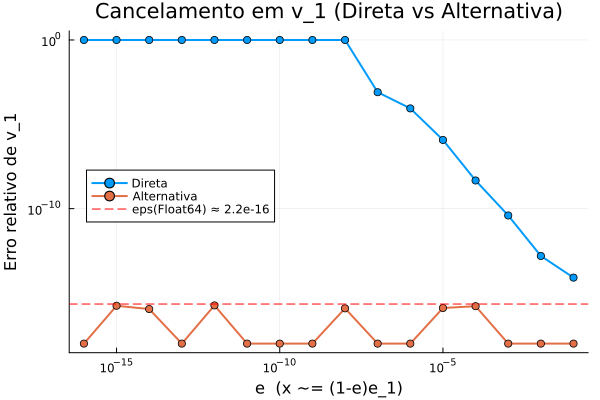

In [25]:
using Plots

epsilons = [10.0^(-k) for k in 1:16]
erros_direto = Float64[]
erros_alt = Float64[]

for e in epsilons
    x    = [1 - e, e/sqrt(2), e/sqrt(2)]
    nrmx = norm(x)
    
    v1_direto = x[1] - nrmx
    nrmy2 = x[2]^2 + x[3]^2
    v1_alt    = -nrmy2 / (x[1] + nrmx)
    
    x_big = BigFloat.(x)
    v1_exato = x_big[1] - norm(x_big)
    
    err_d = abs(v1_direto - Float64(v1_exato)) / abs(Float64(v1_exato))
    err_a = abs(v1_alt - Float64(v1_exato)) / abs(Float64(v1_exato))
    
    # max() evita que o erro seja exatamente 0.0 e quebre a escala log10
    push!(erros_direto, max(err_d, 1e-18))
    push!(erros_alt, max(err_a, 1e-18))
end

plot(epsilons, erros_direto,
     xscale=:log10, yscale=:log10,
     xlabel="e  (x ~= (1-e)e_1)",
     ylabel="Erro relativo de v_1",
     title="Cancelamento em v_1 (Direta vs Alternativa)",
     label="Direta",
     marker=:circle, lw=2, legend=:left)

plot!(epsilons, erros_alt,
      label="Alternativa",
      marker=:circle, lw=2)

# Linha de referência: eps Float64
hline!([eps(Float64)], linestyle=:dash, color=:red, label="eps(Float64) ≈ 2.2e-16")

O gráfico e a tabela acima confirmam que, à medida que $\epsilon \to 0$ (i.e., $x \to e_1$), o erro relativo de $v_1$ calculado diretamente cresce até a ordem da precisão da máquina (100% de erro). Além disso, a fórmula alternativa $v_1 = -\|y\|^2/(x_1 + \|x\|)$ não sofre esse problema como podemos ver também (no gráfico ficam na linha da precisão da máquina e na tabela essa fórmula permite ter mais precisão, enquanto a fórmula direta colapsa no zero).